In [ ]:
import zipfile
import os
import pandas as pd

In [ ]:
def unzip_and_load_data(zip_file_path, extract_to='.'):
    extracted_files = []

    if not os.path.exists(zip_file_path):
        raise FileNotFoundError(f"The zip file {zip_file_path} does not exist.")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
        extracted_files = zip_ref.namelist()
    extracted_file_paths = [os.path.join(extract_to, file) for file in extracted_files]

    return extracted_file_paths

def load_csv(file_path):
    return pd.read_csv(file_path)

In [ ]:
zip_file = 'playground-series-s4e12.zip'
test_data, train_data, sample_submission_data = None, None, None

extracted_files = unzip_and_load_data(zip_file, ".")
for file in extracted_files:
    if file.endswith('./train.csv'):
        train_df = load_csv(file)
    if file.endswith('/test.csv'):
        test_df = load_csv(file)
    if file.endswith('/sample_submission.csv'):
        sample_submission_df = load_csv(file)

In [ ]:
train_df = train_df.drop(columns=['Policy Start Date'])

In [ ]:
for col in train_df.columns:
    if(train_df[col].dtype == 'object'):
        col_labels = train_df[col].unique()
        n = len(col_labels)
        for i in range(n):
            train_df[col] = train_df[col].replace({col_labels[i]: i})

<ipython-input-11-04ccd612f748>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[col] = train_df[col].replace({col_labels[i]: i})


In [ ]:
train_df = train_df.dropna()

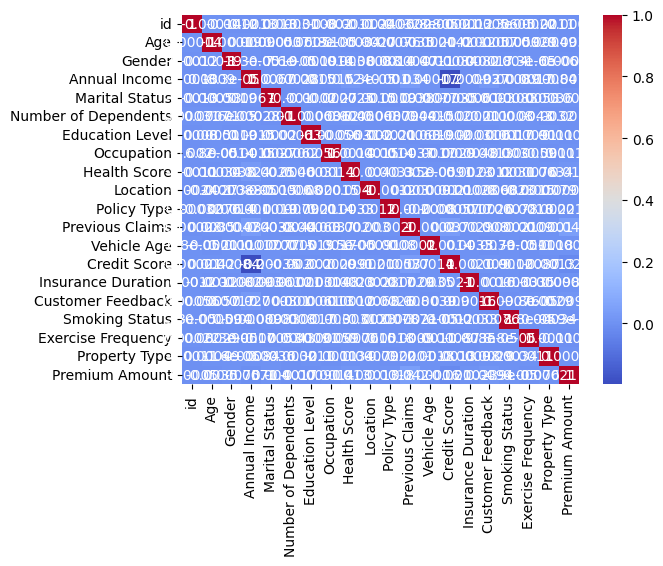

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 14))

sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Example: Using Random Forest for feature importance
X = train_df.drop("Premium Amount", axis=1)
y = train_df["Premium Amount"]

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_
print(importances)

NameError: name 'train_df' is not defined

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
reduced_data = pca.fit_transform(train_df.select_dtypes(include=['float64', 'int64']))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
x_train = train_df.drop(columns=['Premium Amount', 'Gender', 'Number of Dependents', 'Occupation', 'Location',
                                 'Policy Type', 'Previous Claims', 'Vehicle Age', 'Smoking Status', 'Exercise Frequency', 'Property Type'])
y_train = train_df['Premium Amount']

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

In [ ]:
x_tensor = tf.convert_to_tensor(x_train_scaled, dtype=tf.float32)
y_tensor = tf.convert_to_tensor(y_train, dtype=tf.float32)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((x_tensor, y_tensor))

In [ ]:
batch_size = 32
dataset = dataset.batch(batch_size)

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    history_dict = history.history

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_dict['accuracy'], label='Training Accuracy', color='blue')
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', color='orange')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_dict['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history_dict:
        plt.plot(history_dict['val_loss'], label='Validation Loss', color='orange')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(11,),
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error', metrics=['accuracy'])

history = model.fit(dataset, epochs=10)
plot_training_history(history)